# Output-Distribution Diagnostics (Section 3.3, Alternative Form)

True Bland-Altman needs a second rater the project doesn't have and can't get
without new data collection - permanently out of scope until an external
reference exists (3.0). The review's alternative form needs no reference at
all: three plots against the model's own real outputs - rating vs minutes,
rating vs supremacy scalar, and the output histogram - which give most of
Bland-Altman's diagnostic value (where and how the model compresses) using
only what's already in hand.

**Scope note, different from every other notebook in this project**: this one
includes *all* outfield performances, single- and multi-position both (2191
total, vs the 2113 single-position-only figure everywhere else) - the point
here is characterising the output distribution as a user actually sees it,
not isolating a single position's mechanism, so restricting to single-position
would leave out real user-facing output.

**A stray earlier attempt (`ratings_overview.ipynb`) doesn't count as having
done this.** It used the stored `match_rating` field - a previous algorithm
version's output, explicitly disallowed as any kind of reference by the
critical review's own ground rules - and applied a literal Bland-Altman
function to a rating-vs-minutes comparison, which isn't a two-rater agreement
question in the first place. This notebook supersedes it.

## Setup

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path("..").resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

matches_path = project_root / "tests" / "fixtures" / "full_example_data" / "data" / "valencia_cf_1" / "matches.json"

from src.services.analytics.match_ratings_service import MatchRatingsService

with open(project_root / "config" / "performance_weights.json", "r") as f:
    weights = json.load(f)
with open(project_root / "config" / "performance_means_stds.json", "r") as f:
    means_stds = json.load(f)
with open(matches_path, "r") as f:
    data = json.load(f)

service = MatchRatingsService(weights, means_stds)

## Collect every outfield rating, minutes, and supremacy scalar

Supremacy scalar is recomputed once per match (it's a match-level, not
player-level, quantity) using the same home/away xG resolution logic as
`calculate_outfield_rating` itself, calling the real
`_calculate_match_supremacy_scalar` directly.

In [2]:
records = []
for match in data:
    match_overview = match['data']
    half_length = match_overview['half_length']
    is_home = match_overview.get('home_team_name') == "Valencia CF"
    if is_home:
        team_xg = match_overview.get('home_stats', {}).get('xg', 0)
        opp_xg = match_overview.get('away_stats', {}).get('xg', 0)
    else:
        team_xg = match_overview.get('away_stats', {}).get('xg', 0)
        opp_xg = match_overview.get('home_stats', {}).get('xg', 0)
    supremacy = service._calculate_match_supremacy_scalar(team_xg=team_xg, xg_against=opp_xg)

    for perf in match['player_performances']:
        if perf['performance_type'] != 'Outfield':
            continue
        rating = service.calculate_outfield_rating(perf, match_overview, half_length, "Valencia CF")
        if rating is None:
            continue
        positions = perf.get('positions_played', [])
        records.append({
            'match_id': match['id'], 'player_id': perf['player_id'],
            'rating': rating, 'minutes_played': perf.get('minutes_played', 0),
            'supremacy_scalar': supremacy, 'n_positions': len(positions),
            'primary_position': positions[0] if positions else None,
        })

output_df = pd.DataFrame(records)
print(f"Total outfield ratings captured: {len(output_df)}")
print(f"Single-position: {(output_df['n_positions']==1).sum()}, multi-position: {(output_df['n_positions']>1).sum()}")

Total outfield ratings captured: 2191
Single-position: 2115, multi-position: 76


**Result: 2191 outfield ratings captured** - 2115 single-position, 76 multi-position.

## Plot 1: rating vs minutes played

Individual performances plus a 5-minute binned mean overlay, against the
sigmoid midpoint (z=0 → 6.0) as a reference line.

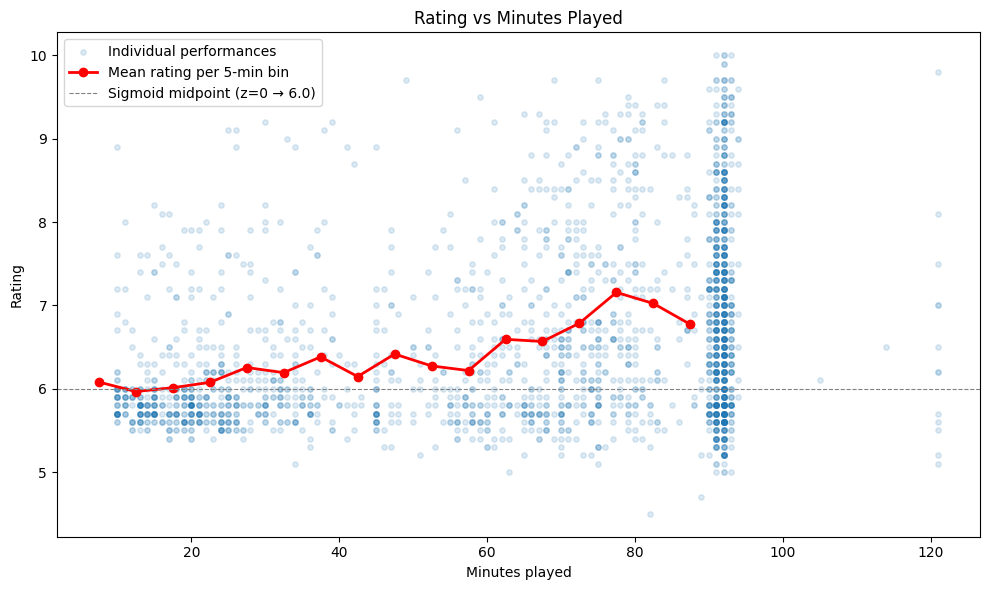

                mean  count
minute_bin                 
(5, 10]     6.080556     36
(10, 15]    5.966667    123
(15, 20]    6.012308    130
(20, 25]    6.076000    125
(25, 30]    6.254545     77
(30, 35]    6.192958     71
(35, 40]    6.382222     45
(40, 45]    6.146341     41
(45, 50]    6.416129     31
(50, 55]    6.273529     34
(55, 60]    6.218072     83
(60, 65]    6.592683     82
(65, 70]    6.566935    124
(70, 75]    6.786429    140
(75, 80]    7.155833    120
(80, 85]    7.022642     53
(85, 90]    6.771845    103


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(output_df['minutes_played'], output_df['rating'], alpha=0.15, s=15, label='Individual performances')

bins = np.arange(0, 95, 5)
output_df['minute_bin'] = pd.cut(output_df['minutes_played'], bins)
binned = output_df.groupby('minute_bin', observed=True)['rating'].agg(['mean', 'count'])
bin_centers = [interval.mid for interval in binned.index]
ax.plot(bin_centers, binned['mean'], color='red', linewidth=2, marker='o', label='Mean rating per 5-min bin')

ax.axhline(6.0, color='gray', linestyle='--', linewidth=0.8, label='Sigmoid midpoint (z=0 → 6.0)')
ax.set_xlabel('Minutes played')
ax.set_ylabel('Rating')
ax.set_title('Rating vs Minutes Played')
ax.legend()
plt.tight_layout()
plt.show()

print(binned)

**Result: a real low band, but not the uniform "cameo compression regardless
of performance" story as stated.** Ratings sit close to 6.0 (5.97-6.08) for the
10-25 minute range, then climb fairly steadily through the middle of the
range up to a peak of 7.16 at 75-80 minutes - before **dipping to 6.77 at
85-90 minutes**, below the 75-80 minute peak. That dip is the interesting
part, and it isn't explained yet by this plot alone - see the by-position
breakdown below.

## Plot 1b: same, by position group

The extension - checking whether the pooled pattern above (and specifically
the 85-90 minute dip) is uniform across positions or a composition effect.

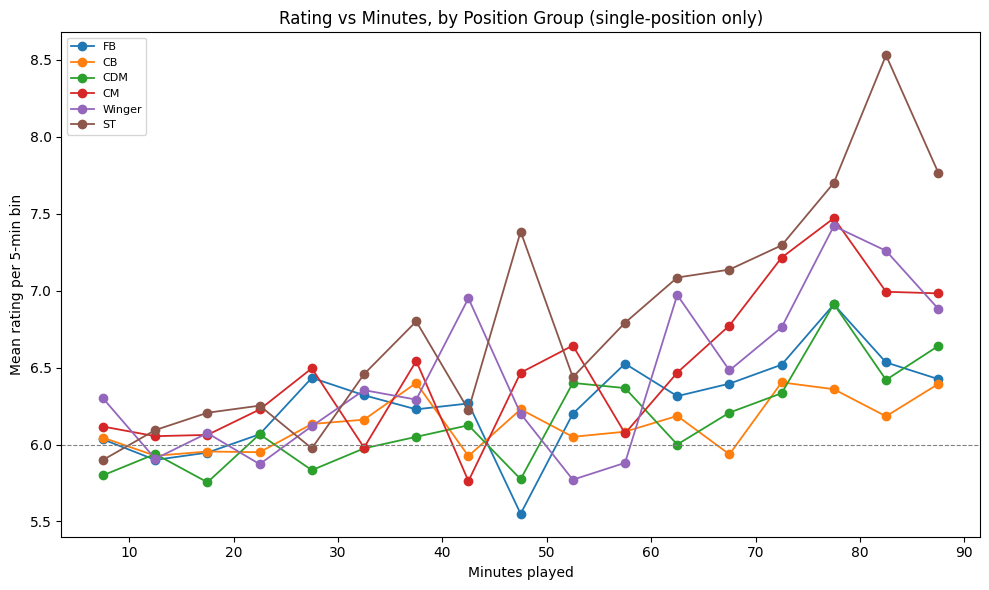

In [4]:
POSITION_GROUP_MAP = {'ST':'ST','LW':'Winger','RW':'Winger','CM':'CM','CDM':'CDM','CB':'CB','LB':'FB','RB':'FB'}
output_df['group'] = output_df['primary_position'].map(POSITION_GROUP_MAP)

fig, ax = plt.subplots(figsize=(10, 6))
for group in output_df['group'].dropna().unique():
    sub = output_df[(output_df['group'] == group) & (output_df['n_positions'] == 1)]
    binned = sub.groupby(pd.cut(sub['minutes_played'], bins), observed=True)['rating'].mean()
    bin_centers = [interval.mid for interval in binned.index]
    ax.plot(bin_centers, binned.values, marker='o', label=group, linewidth=1.3)

ax.axhline(6.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Minutes played')
ax.set_ylabel('Mean rating per 5-min bin')
ax.set_title('Rating vs Minutes, by Position Group (single-position only)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Result: not uniform - the pooled dip is very likely a position-composition
effect, not a genuine high-minutes compression mechanism.** CB and CDM stay
flat and low (roughly 5.8-6.4) across almost the *entire* minutes range,
barely climbing even at 90 minutes. ST climbs steeply and keeps climbing,
reaching 7.7-8.5 in the 75-90 minute range. FB and Winger sit in between.
CB and CDM structurally play more full 90-minute shifts than ST/Winger
(consistent with the ceiling-comparability notebook's own finding that they
have lower structural ceilings and are less often rotated/subbed for tactical
reasons) - so the pooled plot's dip at 85-90 minutes is plausibly just "more
CB/CDM performances landing in that bin, pulling the pooled mean down," not a
genuine "high minutes gets compressed" mechanism acting on every position
alike. This is the same lesson the attribution notebook already surfaced
twice (the team-context correlation, and the impact-scalar's tier-dependence
correcting an initial pooled-mean claim): **pooled means can manufacture
patterns a stratified view shows aren't real in the form first stated.**

Caveat on this specific plot: several lines are visibly noisy (Winger dips to
5.77 at the 42.5-minute bin then spikes to 7.39 at the very next bin) - almost
certainly small-sample artefacts at the position × 5-minute-bin grain (some
cells here likely have single-digit counts), not real structure. Read the
broad slopes, not the individual zigzags.

## Plot 2: rating vs match supremacy scalar

One point of real correction before the plot: an earlier notebook's finding
that "the siege-bonus branch has never activated across the dataset" turns
out to be wrong, checked directly here rather than assumed from that earlier
claim.

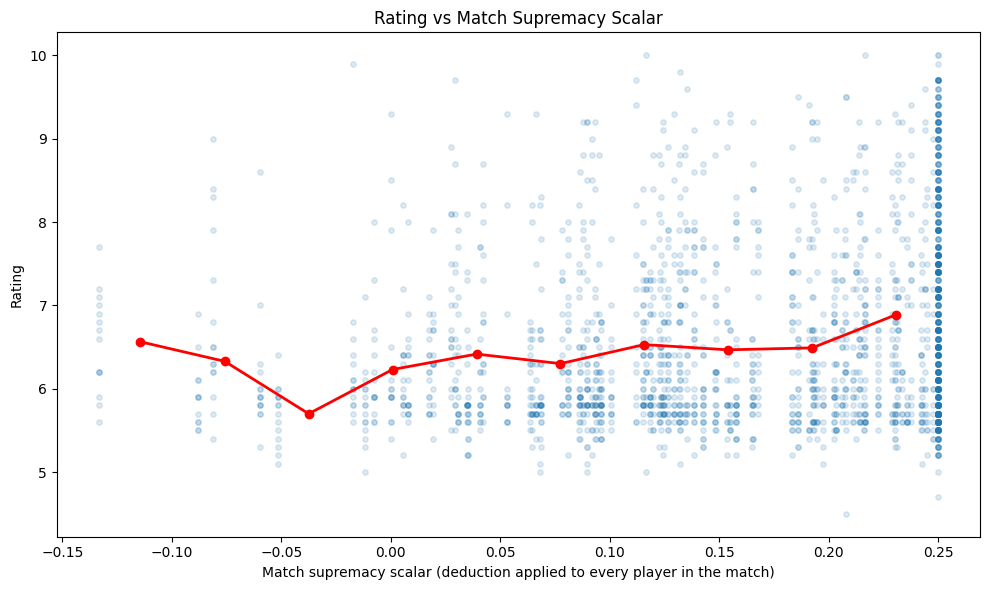

                        mean  count
supremacy_scalar                   
(-0.134, -0.095]    6.564286     14
(-0.095, -0.0566]   6.328571     42
(-0.0566, -0.0183]  5.700000     15
(-0.0183, 0.02]     6.230769    117
(0.02, 0.0584]      6.415789    114
(0.0584, 0.0967]    6.301493    268
(0.0967, 0.135]     6.529577    284
(0.135, 0.173]      6.466834    199
(0.173, 0.212]      6.490417    240
(0.212, 0.25]       6.889421    898

Supremacy scalar range: -0.133 to 0.250
% of performances with supremacy_scalar > 0 (a deduction): 94.1%


In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(output_df['supremacy_scalar'], output_df['rating'], alpha=0.15, s=15)

supremacy_bins = pd.cut(output_df['supremacy_scalar'], bins=10)
binned_sup = output_df.groupby(supremacy_bins, observed=True)['rating'].agg(['mean', 'count'])
bin_centers = [interval.mid for interval in binned_sup.index]
ax.plot(bin_centers, binned_sup['mean'], color='red', linewidth=2, marker='o')

ax.set_xlabel('Match supremacy scalar (deduction applied to every player in the match)')
ax.set_ylabel('Rating')
ax.set_title('Rating vs Match Supremacy Scalar')
plt.tight_layout()
plt.show()

print(binned_sup)
print(f"\nSupremacy scalar range: {output_df['supremacy_scalar'].min():.3f} to {output_df['supremacy_scalar'].max():.3f}")
print(f"% of performances with supremacy_scalar > 0 (a deduction): {(output_df['supremacy_scalar'] > 0).mean():.1%}")

**Result: the siege-bonus branch does activate, just less often than the
deduction branch - the earlier "never activates" claim needs correcting.**
`supremacy_scalar` ranges from **-0.133 to +0.25**, and **5.9% of
performances have a negative value** (a bonus, not a deduction) - not the
theoretical floor of -0.35, but clearly non-trivial and real. This should be
corrected wherever the "never activates" claim was previously stated.

**The negative-scalar bins don't show what "siege bonus" would suggest,
though, and this plot can't resolve why.** Ratings get *worse*, not better,
moving into negative-scalar territory - the `(-0.0566, -0.0183]` bin has the
single lowest mean in the entire table (5.70), and even the most extreme
negative bin only recovers to 6.56 (n=14, likely noisy given the small
sample). The likely explanation: this is a **correlational plot that can't
separate the scalar's own mechanical subtraction from what kind of match
produces that scalar value** - when Valencia is genuinely being outplayed
(negative scalar), individual box-score stats are plausibly worse across the
board too, independent of the scalar's own contribution to the rating. The
attribution notebook's *ablation* approach was specifically built to isolate
a mechanism's own contribution from this kind of confound (holding everything
else fixed, zeroing just the one term) - this plot, being purely
correlational, can't do that, and shouldn't be read as showing the scalar
itself has a "backwards" effect. Flagged as a limitation of this specific
diagnostic, not resolved here.

**94.1% of performances carry a positive (deduction) scalar** - confirms the
sensitivity notebook's broader point that Valencia's structural xG dominance
makes the deduction branch the default state for the overwhelming majority of
performances, even though the bonus branch isn't literally unreachable as
previously stated.

## Plot 3: output rating histogram

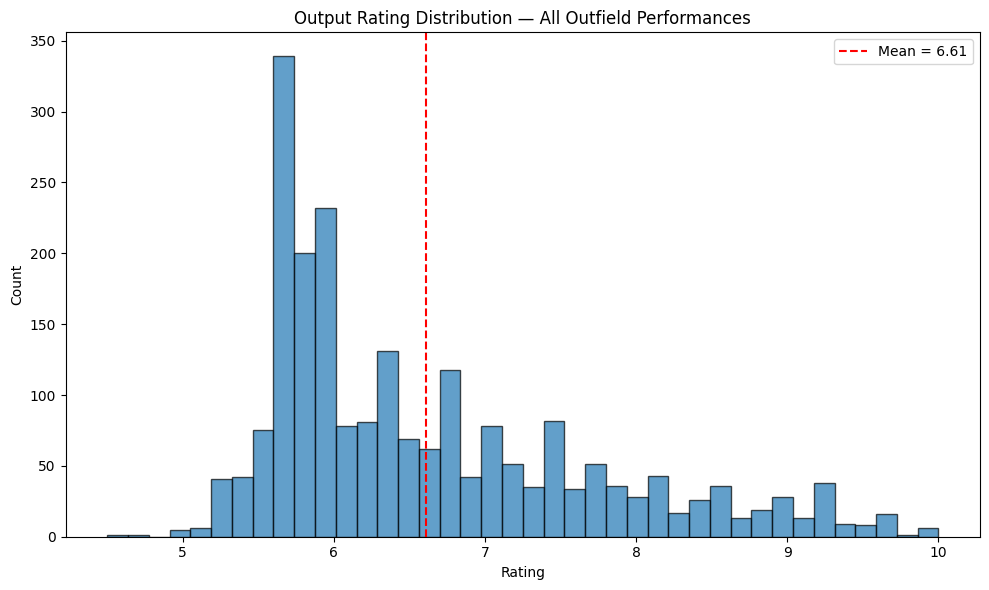

count    2191.000000
mean        6.607987
std         1.080362
min         4.500000
25%         5.800000
50%         6.200000
75%         7.200000
max        10.000000
Name: rating, dtype: float64

% of all ratings falling in the 5.5-6.5 band: 55.0%


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(output_df['rating'], bins=40, edgecolor='black', alpha=0.7)
ax.axvline(output_df['rating'].mean(), color='red', linestyle='--', label=f"Mean = {output_df['rating'].mean():.2f}")
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.set_title('Output Rating Distribution — All Outfield Performances')
ax.legend()
plt.tight_layout()
plt.show()

print(output_df['rating'].describe())
band = output_df['rating'].between(5.5, 6.5).mean()
print(f"\n% of all ratings falling in the 5.5-6.5 band: {band:.1%}")

**Result: compression is real but partial, not total - "tightly piled with
thin tails" overstates what's actually here.** 55.0% of ratings fall in the
5.5-6.5 band, and the single tallest bar (5.5-5.75ish, 339 performances) does
dominate visually - so the low-mode compression Part 1 describes is genuinely
there. But 45% of ratings fall *outside* that band, and the right tail out to
9.5-10 is visibly substantial, not a sparse trickle - chunky bars the entire
way up, consistent with everything else this project has found about
ST/Winger/CM routinely reaching high ratings via event bonus. A more accurate
restatement: **a dominant low mode with a real, substantial right tail**, not
a tight, thin-tailed distribution.

Mean 6.61, median 6.20 - the mean sitting meaningfully above the median
confirms the right-skew directly (a symmetric or left-skewed distribution
would show the reverse ordering).

**One comparison this notebook can't complete**: the review also asks to
compare this spread against the commercial rating scale's known spread from
the original research document. That figure isn't available in this
notebook's context - flagged as an open item rather than invented.

## Caveats

- **Correlational throughout, not causal.** All three plots show what the
  output distribution looks like, not why - in particular, Plot 2 cannot
  separate the supremacy scalar's own mechanical effect from the confound
  that dominant/non-dominant matches likely also differ in underlying player
  stats. Where this project has needed to isolate a mechanism's own
  contribution, the attribution notebook's ablation approach has been the
  right tool - not attempted here, since this notebook's purpose is
  characterising the real output distribution as a user sees it, not
  decomposing it.
- **Position-composition confounds pooled means throughout**, most visibly
  in Plot 1's 85-90 minute dip. Any future diagnostic on this dataset should
  default to a position-stratified view before trusting a pooled pattern,
  consistent with what the attribution and this notebook have both now found
  independently.
- **The by-position minutes plot (Plot 1b) is noisy at the position ×
  5-minute-bin grain** - some cells likely have single-digit sample sizes.
  Read broad slopes, not individual zigzags; a formal thin-cell check (as
  used throughout the attribution and ceiling-comparability notebooks) wasn't
  run here since this notebook is diagnostic/visual rather than a formal
  statistical test.
- **The commercial-scale spread comparison (part of the review's original
  ask for this section) is not completed** - the reference figure from the
  research document isn't available in this notebook's context.
- **This notebook includes multi-position performances** (76 of 2191),
  unlike every other notebook in this project. Multi-position ratings go
  through the Alpha-Drag hybrid blend, a different mechanism than the
  single-position pipeline everything else here has analysed - their
  inclusion is appropriate for characterising real user-facing output, but
  means this notebook's dataset isn't directly comparable row-for-row with
  the single-position-only datasets built elsewhere in this project.

## Conclusions

**What this notebook set out to do**: complete the one part of Section 3.3
that doesn't require an external reference - three diagnostic plots against
the model's own real output - since true Bland-Altman remains permanently
blocked without new data collection.

### The Part 1 compression story holds up, but needs restating more precisely

Central compression is real (55% of ratings in the 5.5-6.5 band, a dominant
low histogram mode, a genuine low band at 10-25 minutes) but **partial, not
total** - a substantial, non-thin right tail exists (45% of ratings, chunky
bars out to 9.5-10), and the specific claim of compression scaling uniformly
with minutes doesn't survive position-stratification: CB/CDM stay flat and
low across nearly the whole minutes range while ST climbs steeply, meaning
what looks like "high minutes gets compressed too" in the pooled view is
substantially a position-composition effect, not a uniform mechanism. The
whitepaper should state the compression finding with this more precise
framing rather than the original "cameos collapse toward 6.0 regardless of
performance" language, which slightly overstates both how total the
compression is and how uniformly it applies across positions.

### A real correction to carry back to earlier work

**The siege-bonus branch of the supremacy scalar does activate** (5.9% of
performances, range down to -0.133) - an earlier notebook's claim that it
"has never activated across the dataset" is wrong and should be corrected
wherever it was stated. The bonus branch is rare relative to the deduction
branch (94.1% of performances carry a deduction), which is likely why it was
missed or dismissed as noise previously, but rare isn't the same as never.

### What this notebook adds, beyond the three requested plots

The position-stratified minutes plot (Plot 1b) wasn't explicitly requested by
the review but was worth adding given three separate prior notebooks
(attribution's team-context correlation, attribution's impact-scalar
tier-dependence correction, ceiling-comparability's structural-ceiling
ranking) had already established that pooled means in this project routinely
obscure position-dependent structure. That pattern held a fourth time here.

### Open threads for later work

- The commercial-scale spread comparison, pending the reference figure from
  the original research document.
- A formal decomposition of *why* negative-supremacy-scalar performances
  rate lower (Plot 2's puzzle) - whether it's genuinely a stats-quality
  confound as hypothesised, or something else, would need an ablation-style
  approach rather than this notebook's correlational one.
- A thin-cell check on the position × minute-bin grain in Plot 1b, if that
  breakdown is going to be relied on for anything beyond the broad-slope
  reading given here.